# Phishing Detection under LLM Distribution Shift

**Curso:** CC3094 - Security Data Science  
**Proyecto:** Robustez de modelos de detección de phishing entrenados con correos humanos frente a correos generados por modelos de lenguaje grandes
**Miembros:** Edwin Ortega - 22305 y Esteban Zambrano 22119

### Objetivo de esta fase
En esta etapa se selecciona y prepara el dataset a utilizar, se realiza un análisis exploratorio de datos (EDA) y se generan/seleccionan características relevantes para la posterior implementación del modelo.

### Enfoque del proyecto
Aunque el dataset incluye correos humanos y correos generados por LLM, el objetivo final del proyecto es evaluar la robustez de modelos entrenados con correos humanos cuando se enfrentan a correos generados por LLM, sin reentrenamiento.

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
# Encontrar la carpeta data

def find_data_dir():
    candidates = [Path("data"), Path("../data")]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("No se encontró la carpeta 'data' ni en la raíz ni en el nivel superior.")

DATA_DIR = find_data_dir()
DATA_DIR

WindowsPath('../data')

In [3]:
# Función especial para leer el CSV

def read_llm_phishing_broken_csv(file_path):
    rows = []
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    # Saltar encabezado
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        
        # Separar por la última coma para recuperar text,label
        try:
            text, label = line.rsplit(",", 1)
            rows.append({"text": text.strip(), "label": int(label.strip())})
        except ValueError:
            # Si alguna línea no se puede parsear, se ignora
            continue

    return pd.DataFrame(rows)

In [4]:
# Cargar los 4 datasets

human_legit = pd.read_csv(DATA_DIR / "human-generated" / "legit.csv")
human_phishing = pd.read_csv(DATA_DIR / "human-generated" / "phishing.csv")
llm_legit = pd.read_csv(DATA_DIR / "llm-generated" / "legit.csv")
llm_phishing = read_llm_phishing_broken_csv(DATA_DIR / "llm-generated" / "phishing.csv")

datasets = {
    "human_legit": human_legit,
    "human_phishing": human_phishing,
    "llm_legit": llm_legit,
    "llm_phishing": llm_phishing
}

# Cargar los 4 datasets

human_legit = pd.read_csv(DATA_DIR / "human-generated" / "legit.csv")
human_phishing = pd.read_csv(DATA_DIR / "human-generated" / "phishing.csv")
llm_legit = pd.read_csv(DATA_DIR / "llm-generated" / "legit.csv")
llm_phishing = read_llm_phishing_broken_csv(DATA_DIR / "llm-generated" / "phishing.csv")

datasets = {
    "human_legit": human_legit,
    "human_phishing": human_phishing,
    "llm_legit": llm_legit,
    "llm_phishing": llm_phishing
}

In [5]:
# Inspección inicial

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 60)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head(2))


human_legit
------------------------------------------------------------
Shape: (1000, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']


,sender,receiver,date,subject,body,urls,label
0,Jesus Miguel Recuenco Ezquerra <JMRECU@teleline.es>,handy board <handyboard@media.mit.edu>,2019-10-29 22:53:50,Starting IC with wizard,"Hi\r\n\r\n\t\tI am running the IR test program from Max Davies. To do this I need to start\r\nIC with thw wizard option. As I have a macintosh, there is a wizard option for\r\nthe mac version of I...",0,0
1,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:53:26,Trade Me -- A question on your auction: Auction 130939357 for Small\tbookshelf,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nSecurity Note: Trade Me will never ask you for your password via email\r\n\r\n\r\n\r\nThis is an automated email regarding listing reference: 13...,0,0



human_phishing
------------------------------------------------------------
Shape: (1000, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']


,sender,receiver,date,subject,body,urls,label
0,MetaMask <info@sofamekar.com>,jose@monkey.org,2022-12-27 10:56:49,Your MetaMask wallet will be suspended,"Verify your MetaMask Wallet Our system has shown that your MetaMask wallet has not yet been verified, this verification can be done easily via the button below. Unverified accounts will be suspe...",1,1
1,MetaMask <info@sofamekar.com>,jose@monkey.org,2022-12-27 10:56:49,Your MetaMask wallet will be suspended,"Verify your MetaMask Wallet Our system has shown that your MetaMask wallet has not yet been verified, this verification can be done easily via the button below. Unverified accounts will be suspe...",1,1



llm_legit
------------------------------------------------------------
Shape: (1000, 2)
Columns: ['text', 'label']


,text,label
0,"Dear Michael, I hope this message finds you well. We are reaching out to you with an urgent request regarding your account verification. As part of our commitment to ensuring the security of our u...",1
1,"Dear Jennifer, We hope you're doing well. We're writing to remind you of the importance of verifying your account with us. Your account security is paramount to us, and completing this verificatio...",1



llm_phishing
------------------------------------------------------------
Shape: (1000, 2)
Columns: ['text', 'label']


,text,label
0,"Dear User, We have received reports indicating that your account has been flagged for suspicious activities. To ensure the safety of your account and prevent any unauthorized access, we require yo...",1
1,"Dear Sarah Thompson, I hope this email finds you in good health. My name is Jessica Wilson, and I'm a senior recruiter at Global Solutions. We recently came across your profile on a renowned job p...",1


In [6]:
# Verificación de nulos, duplicados y 

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 60)
    print("Nulos:")
    print(df.isnull().sum())
    print("\nDuplicados:", df.duplicated().sum())
    if "label" in df.columns:
        print("\nDistribución de label:")
        print(df["label"].value_counts(dropna=False))


human_legit
------------------------------------------------------------
Nulos:
sender       0
receiver    16
date         0
subject      0
body         0
urls         0
label        0
dtype: int64

Duplicados: 0

Distribución de label:
label
0    1000
Name: count, dtype: int64

human_phishing
------------------------------------------------------------
Nulos:
sender       0
receiver    22
date         0
subject      2
body         0
urls         0
label        0
dtype: int64

Duplicados: 496

Distribución de label:
label
1    1000
Name: count, dtype: int64

llm_legit
------------------------------------------------------------
Nulos:
text     0
label    0
dtype: int64

Duplicados: 2

Distribución de label:
label
1    1000
Name: count, dtype: int64

llm_phishing
------------------------------------------------------------
Nulos:
text     0
label    0
dtype: int64

Duplicados: 0

Distribución de label:
label
1    1000
Name: count, dtype: int64


## Estandarización del dataset

Los archivos humanos y los generados por LLM no tienen exactamente la misma estructura:
- Los correos humanos incluyen columnas como `subject`, `body`, `urls`, `sender`, etc.
- Los correos LLM contienen principalmente una columna `text`.

Para unificar el análisis, se construirá un dataset común con las siguientes columnas principales:

- `text`: texto completo del correo
- `source_type`: `human` o `llm`
- `email_group`: `legit` o `phishing`
- `label_binary`: 0 para legítimo, 1 para phishing

Además, se conservarán metadatos originales cuando estén disponibles.

In [7]:
# Funciones para unificar formato

def combine_human_email_text(df):
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)
    return (subject + " " + body).str.strip()

def standardize_human_df(df, email_group):
    out = df.copy()
    out["text"] = combine_human_email_text(out)
    out["source_type"] = "human"
    out["email_group"] = email_group
    out["label_binary"] = 0 if email_group == "legit" else 1
    return out[[
        "text", "label_binary", "source_type", "email_group",
        "sender", "receiver", "date", "subject", "body", "urls", "label"
    ]]

def standardize_llm_df(df, email_group):
    out = df.copy()
    out["text"] = out["text"].fillna("").astype(str)
    out["source_type"] = "llm"
    out["email_group"] = email_group
    out["label_binary"] = 0 if email_group == "legit" else 1
    return out[["text", "label_binary", "source_type", "email_group", "label"]]

In [8]:
# Unificar datasets

human_legit_std = standardize_human_df(human_legit, "legit")
human_phishing_std = standardize_human_df(human_phishing, "phishing")
llm_legit_std = standardize_llm_df(llm_legit, "legit")
llm_phishing_std = standardize_llm_df(llm_phishing, "phishing")

df_all = pd.concat(
    [human_legit_std, human_phishing_std, llm_legit_std, llm_phishing_std],
    ignore_index=True
)

print("Shape del dataset unificado:", df_all.shape)
display(df_all.head())

Shape del dataset unificado: (4000, 11)


,text,label_binary,source_type,email_group,sender,receiver,date,subject,body,urls,label
0,"Starting IC with wizard Hi\r\n\r\n\t\tI am running the IR test program from Max Davies. To do this I need to start\r\nIC with thw wizard option. As I have a macintosh, there is a wizard option for...",0,human,legit,Jesus Miguel Recuenco Ezquerra <JMRECU@teleline.es>,handy board <handyboard@media.mit.edu>,2019-10-29 22:53:50,Starting IC with wizard,"Hi\r\n\r\n\t\tI am running the IR test program from Max Davies. To do this I need to start\r\nIC with thw wizard option. As I have a macintosh, there is a wizard option for\r\nthe mac version of I...",0,0
1,Trade Me -- A question on your auction: Auction 130939357 for Small\tbookshelf \r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nSecurity Note: Trade Me will never ask you for your password via ...,0,human,legit,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:53:26,Trade Me -- A question on your auction: Auction 130939357 for Small\tbookshelf,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nSecurity Note: Trade Me will never ask you for your password via email\r\n\r\n\r\n\r\nThis is an automated email regarding listing reference: 13...,0,0
2,"Trade Me - A request from a Trade Me member. Auction: 129227503 \r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nTrade Me Offer RequestGenerated 8 December, 6:27 AM\r\n\r\n\r\nSecurity Note: Trade Me will ...",0,human,legit,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:45:53,Trade Me - A request from a Trade Me member. Auction: 129227503,"\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nTrade Me Offer RequestGenerated 8 December, 6:27 AM\r\n\r\n\r\nSecurity Note: Trade Me will never ask you for your password via email\r\n\r\nHi Tony,\r\nA T...",0,0
3,"RE: NorthTec Account/Password Hi Tony\r\nNot sure why it didn't work, but I manually set it to that from this end so you should be sweet to log in with that now.\r\n\r\nRegards,\r\nKevin Jacobson\...",0,human,legit,Kevin Jacobson <wffjeanja@northtec.ac.nz>,user2.1@gvc.ceas-challenge.cc,2008-08-06 13:43:27,RE: NorthTec Account/Password,"Hi Tony\r\nNot sure why it didn't work, but I manually set it to that from this end so you should be sweet to log in with that now.\r\n\r\nRegards,\r\nKevin Jacobson\r\n\r\nICT Services\r\nNorthTe...",1,0
4,2008 timetable Kindly suggest changes\r\n\r\n------------------------------------------------\r\nDr. Albert van Aardt\r\nPrincipal Academic Staff Member\r\nNorthland Polytechnic\r\nWhangarei\r\nNe...,0,human,legit,Albert van Aardt <zfdrqfguo@northtec.ac.nz>,user2.1@gvc.ceas-challenge.cc,2008-08-06 13:26:57,2008 timetable,Kindly suggest changes\r\n\r\n------------------------------------------------\r\nDr. Albert van Aardt\r\nPrincipal Academic Staff Member\r\nNorthland Polytechnic\r\nWhangarei\r\nNew Zealand\r\nTe...,0,0


In [9]:
# Revisar posible inconsistencia entre carpetas y labels originales

print("Cruce entre email_group y label original:")
display(pd.crosstab(df_all["email_group"], df_all["label"], dropna=False))

Cruce entre email_group y label original:


label,0,1
email_group,,
legit,1000,1000
phishing,0,2000


## Nota importante sobre las etiquetas

Durante la inspección inicial se observa que algunos archivos no siguen de forma consistente la misma convención en la columna `label`.  
Por esa razón, para esta implementación se utilizará como etiqueta principal `label_binary`, derivada de la carpeta de origen:

- `legit` -> 0
- `phishing` -> 1

La columna `label` original se conserva solo como referencia.

In [10]:
# Limpieza básica del texto

def clean_text(text):
    text = str(text)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_all["text"] = df_all["text"].apply(clean_text)

# Eliminar filas sin texto
df_all = df_all[df_all["text"].str.len() > 0].copy()

print("Shape luego de limpieza básica:", df_all.shape)

Shape luego de limpieza básica: (4000, 11)


In [11]:
# Duplicados

print("Duplicados exactos en el dataset unificado:", df_all.duplicated(subset=["text"]).sum())

duplicates_by_group = (
    df_all.groupby(["source_type", "email_group"])["text"]
    .apply(lambda x: x.duplicated().sum())
    .reset_index(name="duplicate_count")
)

display(duplicates_by_group)

Duplicados exactos en el dataset unificado: 800


,source_type,email_group,duplicate_count
0,human,legit,298
1,human,phishing,500
2,llm,legit,2
3,llm,phishing,0


In [12]:
# Eliminar duplicados por texto

df_all = df_all.drop_duplicates(subset=["text"]).reset_index(drop=True)
print("Shape después de eliminar duplicados por texto:", df_all.shape)

Shape después de eliminar duplicados por texto: (3200, 11)


In [13]:
# Distribución general del dataset

print("Distribución por source_type:")
display(df_all["source_type"].value_counts())

print("\nDistribución por email_group:")
display(df_all["email_group"].value_counts())

print("\nDistribución cruzada:")
display(pd.crosstab(df_all["source_type"], df_all["email_group"]))

Distribución por source_type:


source_type
llm      1998
human    1202
Name: count, dtype: int64


Distribución por email_group:


email_group
legit       1700
phishing    1500
Name: count, dtype: int64


Distribución cruzada:


email_group,legit,phishing
source_type,,
human,702,500
llm,998,1000


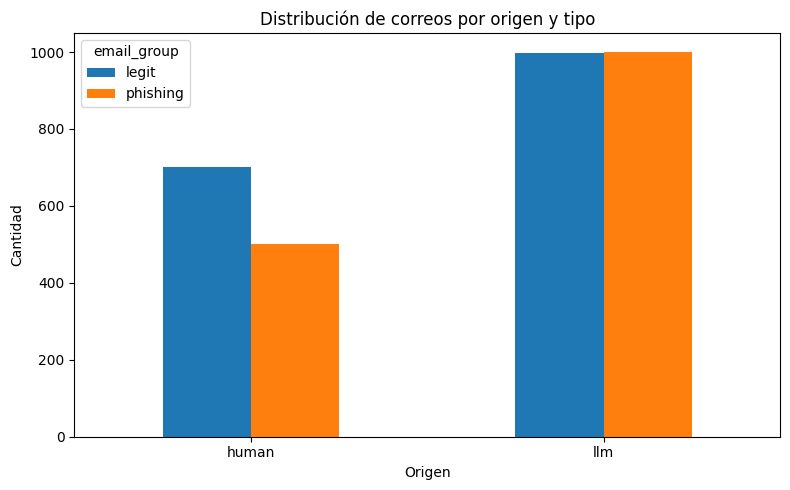

In [14]:
# Gráfica de distribución

cross = pd.crosstab(df_all["source_type"], df_all["email_group"])

cross.plot(kind="bar", figsize=(8, 5))
plt.title("Distribución de correos por origen y tipo")
plt.xlabel("Origen")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Features léxicas básicas

def count_urls(text):
    return len(re.findall(r"(https?://\S+|www\.\S+|\b[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b)", text))

def count_exclamations(text):
    return text.count("!")

def count_questions(text):
    return text.count("?")

def count_uppercase_chars(text):
    return sum(1 for c in text if c.isupper())

def uppercase_ratio(text):
    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return 0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def count_digits(text):
    return sum(1 for c in text if c.isdigit())

def word_count(text):
    return len(text.split())

def char_count(text):
    return len(text)

def avg_word_length(text):
    words = text.split()
    if not words:
        return 0
    return np.mean([len(w) for w in words])

urgent_keywords = [
    "urgent", "immediately", "suspend", "verify", "account",
    "click", "password", "confirm", "security", "limited",
    "warning", "action", "login", "bank", "update"
]

def keyword_count(text, keywords):
    text_lower = text.lower()
    return sum(text_lower.count(k) for k in keywords)

df_all["char_count"] = df_all["text"].apply(char_count)
df_all["word_count"] = df_all["text"].apply(word_count)
df_all["avg_word_length"] = df_all["text"].apply(avg_word_length)
df_all["url_count"] = df_all["text"].apply(count_urls)
df_all["exclamation_count"] = df_all["text"].apply(count_exclamations)
df_all["question_count"] = df_all["text"].apply(count_questions)
df_all["uppercase_count"] = df_all["text"].apply(count_uppercase_chars)
df_all["uppercase_ratio"] = df_all["text"].apply(uppercase_ratio)
df_all["digit_count"] = df_all["text"].apply(count_digits)
df_all["urgent_keyword_count"] = df_all["text"].apply(lambda x: keyword_count(x, urgent_keywords))

display(df_all.head())

,text,label_binary,source_type,email_group,sender,receiver,date,subject,body,urls,label,char_count,word_count,avg_word_length,url_count,exclamation_count,question_count,uppercase_count,uppercase_ratio,digit_count,urgent_keyword_count
0,"Starting IC with wizard Hi I am running the IR test program from Max Davies. To do this I need to start IC with thw wizard option. As I have a macintosh, there is a wizard option for the mac versi...",0,human,legit,Jesus Miguel Recuenco Ezquerra <JMRECU@teleline.es>,handy board <handyboard@media.mit.edu>,2019-10-29 22:53:50,Starting IC with wizard,"Hi\r\n\r\n\t\tI am running the IR test program from Max Davies. To do this I need to start\r\nIC with thw wizard option. As I have a macintosh, there is a wizard option for\r\nthe mac version of I...",0,0,211,44,3.818182,0,0,1,18,0.109756,0,0
1,Trade Me -- A question on your auction: Auction 130939357 for Small bookshelf Security Note: Trade Me will never ask you for your password via email This is an automated email regarding listing re...,0,human,legit,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:53:26,Trade Me -- A question on your auction: Auction 130939357 for Small\tbookshelf,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nSecurity Note: Trade Me will never ask you for your password via email\r\n\r\n\r\n\r\nThis is an automated email regarding listing reference: 13...,0,0,739,127,4.826772,2,1,0,26,0.046181,25,3
2,"Trade Me - A request from a Trade Me member. Auction: 129227503 Trade Me Offer RequestGenerated 8 December, 6:27 AM Security Note: Trade Me will never ask you for your password via email Hi Tony, ...",0,human,legit,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:45:53,Trade Me - A request from a Trade Me member. Auction: 129227503,"\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nTrade Me Offer RequestGenerated 8 December, 6:27 AM\r\n\r\n\r\nSecurity Note: Trade Me will never ask you for your password via email\r\n\r\nHi Tony,\r\nA T...",0,0,358,61,4.885246,0,0,0,27,0.102662,22,2
3,"RE: NorthTec Account/Password Hi Tony Not sure why it didn't work, but I manually set it to that from this end so you should be sweet to log in with that now. Regards, Kevin Jacobson ICT Services ...",0,human,legit,Kevin Jacobson <wffjeanja@northtec.ac.nz>,user2.1@gvc.ceas-challenge.cc,2008-08-06 13:43:27,RE: NorthTec Account/Password,"Hi Tony\r\nNot sure why it didn't work, but I manually set it to that from this end so you should be sweet to log in with that now.\r\n\r\nRegards,\r\nKevin Jacobson\r\n\r\nICT Services\r\nNorthTe...",1,0,3180,562,4.660142,4,0,2,175,0.078829,135,19
4,2008 timetable Kindly suggest changes ------------------------------------------------ Dr. Albert van Aardt Principal Academic Staff Member Northland Polytechnic Whangarei New Zealand Tel. (+64) 0...,0,human,legit,Albert van Aardt <zfdrqfguo@northtec.ac.nz>,user2.1@gvc.ceas-challenge.cc,2008-08-06 13:26:57,2008 timetable,Kindly suggest changes\r\n\r\n------------------------------------------------\r\nDr. Albert van Aardt\r\nPrincipal Academic Staff Member\r\nNorthland Polytechnic\r\nWhangarei\r\nNew Zealand\r\nTe...,0,0,206,24,7.625000,0,0,0,14,0.121739,15,0


In [16]:
# Resumen estadístico de features

feature_cols = [
    "char_count", "word_count", "avg_word_length", "url_count",
    "exclamation_count", "question_count", "uppercase_count",
    "uppercase_ratio", "digit_count", "urgent_keyword_count"
]

display(df_all[feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
char_count,3200.0,1426.254375,4220.037823,54.000000,495.000000,652.000000,980.000000,69997.000000
word_count,3200.0,201.959062,544.734231,2.000000,74.000000,99.000000,147.000000,8605.000000
avg_word_length,3200.0,5.882259,2.440023,3.207547,5.302353,5.614921,5.967479,95.500000
url_count,3200.0,4.770313,26.850915,0.000000,1.000000,1.000000,2.000000,937.000000
exclamation_count,3200.0,0.864688,5.123496,0.000000,0.000000,0.000000,1.000000,177.000000
question_count,3200.0,0.768437,3.799171,0.000000,0.000000,0.000000,0.000000,123.000000
uppercase_count,3200.0,92.731562,472.939032,3.000000,15.000000,20.000000,35.000000,8399.000000
uppercase_ratio,3200.0,0.055183,0.048262,0.010441,0.030217,0.038658,0.061512,0.864198
digit_count,3200.0,66.826250,480.397020,0.000000,0.000000,2.000000,14.000000,9287.000000
urgent_keyword_count,3200.0,3.702187,6.253856,0.000000,1.000000,2.000000,4.000000,124.000000


In [17]:
# Comparación por clase legítimo/phishing

group_stats = df_all.groupby("email_group")[feature_cols].mean().round(2)
display(group_stats)

,char_count,word_count,avg_word_length,url_count,exclamation_count,question_count,uppercase_count,uppercase_ratio,digit_count,urgent_keyword_count
email_group,,,,,,,,,,
legit,1962.70,272.35,5.85,7.37,1.14,1.07,141.27,0.06,113.89,2.81
phishing,818.28,122.18,5.92,1.82,0.55,0.43,37.72,0.05,13.48,4.71


In [18]:
# Comparación específica humano phishing vs llm phishing

phishing_only = df_all[df_all["email_group"] == "phishing"].copy()

display(
    phishing_only.groupby("source_type")[feature_cols].mean().round(2)
)

,char_count,word_count,avg_word_length,url_count,exclamation_count,question_count,uppercase_count,uppercase_ratio,digit_count,urgent_keyword_count
source_type,,,,,,,,,,
human,1140.05,163.90,6.68,3.38,0.66,1.24,79.57,0.10,36.70,6.67
llm,657.40,101.32,5.54,1.04,0.50,0.02,16.80,0.03,1.87,3.74


C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2058119501.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["legit", "phishing"])


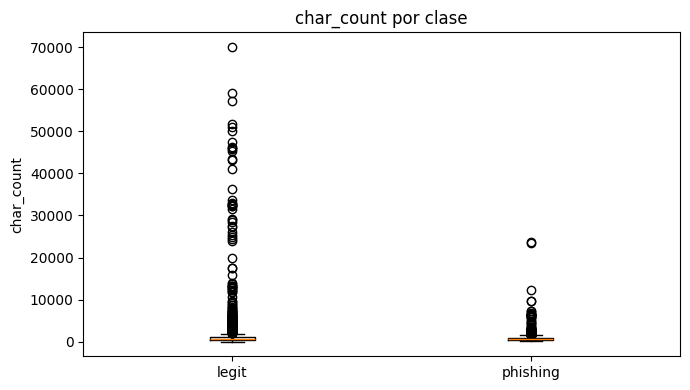

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2058119501.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["legit", "phishing"])


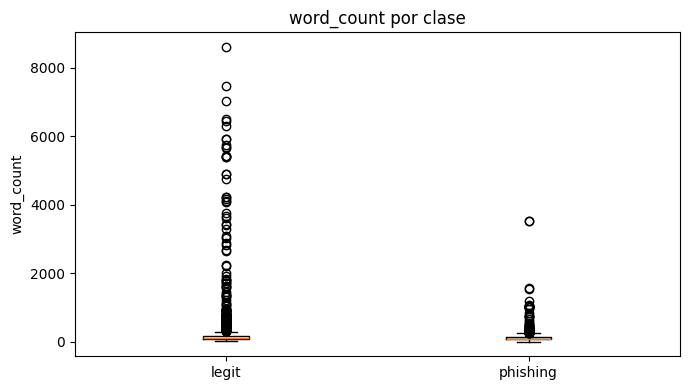

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2058119501.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["legit", "phishing"])


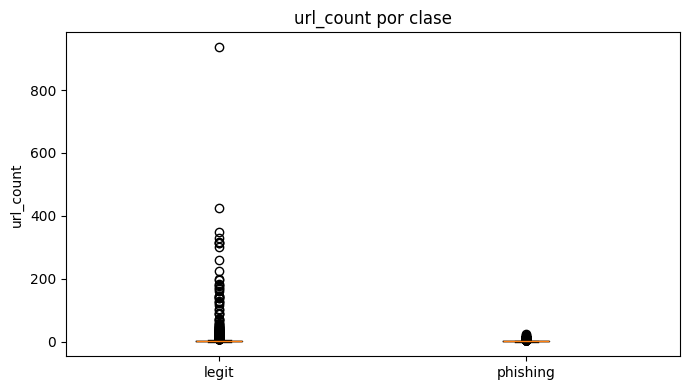

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2058119501.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["legit", "phishing"])


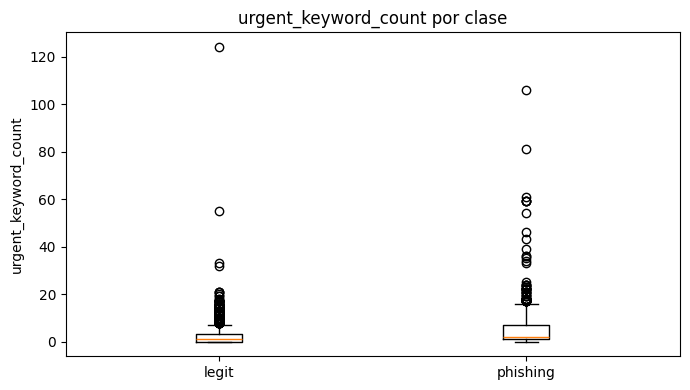

In [19]:
# Boxplots de algunas variables importantes

plot_features = ["char_count", "word_count", "url_count", "urgent_keyword_count"]

for col in plot_features:
    plt.figure(figsize=(7, 4))
    data_to_plot = [
        df_all[df_all["email_group"] == "legit"][col],
        df_all[df_all["email_group"] == "phishing"][col]
    ]
    plt.boxplot(data_to_plot, labels=["legit", "phishing"])
    plt.title(f"{col} por clase")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2423151077.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["human phishing", "llm phishing"])


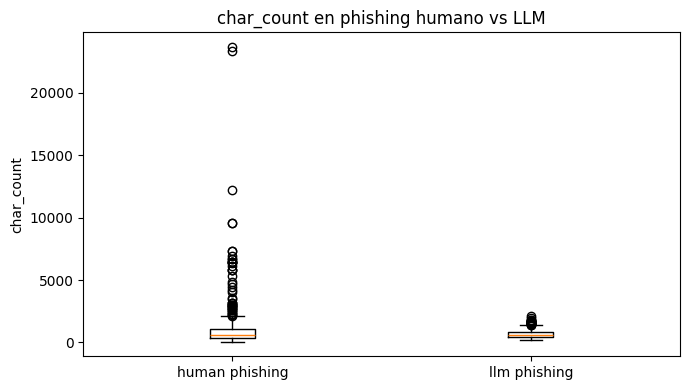

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2423151077.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["human phishing", "llm phishing"])


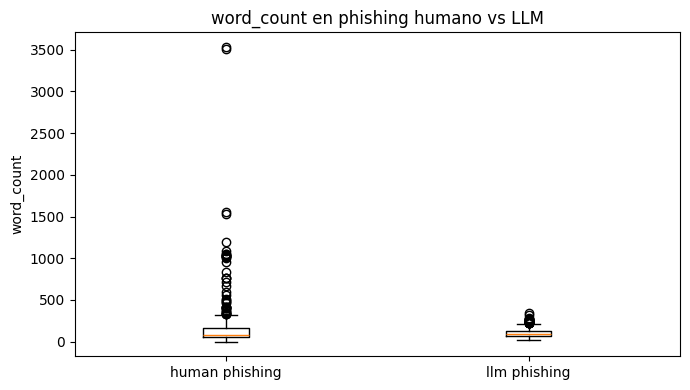

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2423151077.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["human phishing", "llm phishing"])


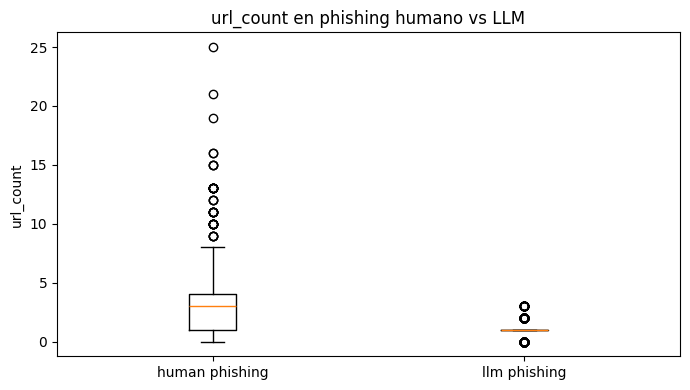

C:\Users\esteb\AppData\Local\Temp\ipykernel_4800\2423151077.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["human phishing", "llm phishing"])


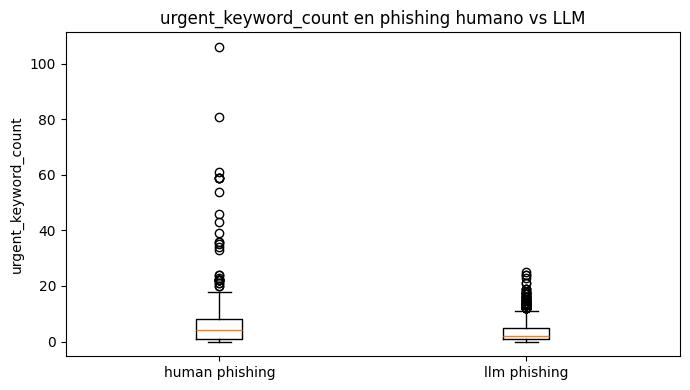

In [20]:
# Boxplots phishing humano vs phishing LLM

for col in plot_features:
    plt.figure(figsize=(7, 4))
    data_to_plot = [
        phishing_only[phishing_only["source_type"] == "human"][col],
        phishing_only[phishing_only["source_type"] == "llm"][col]
    ]
    plt.boxplot(data_to_plot, labels=["human phishing", "llm phishing"])
    plt.title(f"{col} en phishing humano vs LLM")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [21]:
# Palabras más frecuentes por grupo

stopwords_basic = {
    "the", "and", "to", "of", "a", "in", "for", "is", "on", "you", "your",
    "we", "our", "this", "that", "with", "as", "be", "are", "at", "by",
    "an", "or", "from", "it", "please", "have", "has", "will", "if"
}

def tokenize_simple(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    return [w for w in words if w not in stopwords_basic and len(w) > 2]

def top_words(text_series, n=20):
    counter = Counter()
    for text in text_series:
        counter.update(tokenize_simple(text))
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

print("Top palabras - phishing humano")
display(top_words(df_all[(df_all["source_type"] == "human") & (df_all["email_group"] == "phishing")]["text"]))

print("Top palabras - phishing LLM")
display(top_words(df_all[(df_all["source_type"] == "llm") & (df_all["email_group"] == "phishing")]["text"]))

Top palabras - phishing humano


,word,count
0,monkey,967
1,org,929
2,email,915
3,account,860
4,jose,756
5,not,489
6,information,413
7,message,378
8,mail,338
9,update,334


Top palabras - phishing LLM


,word,count
0,link,1259
1,account,1154
2,com,972
3,https,886
4,dear,799
5,regards,707
6,click,632
7,email,629
8,hope,601
9,opportunity,574


In [22]:
# Preparar subconjuntos del experimento final

train_human = df_all[df_all["source_type"] == "human"].copy()
test_llm = df_all[df_all["source_type"] == "llm"].copy()

print("Train (solo humanos):", train_human.shape)
print("Test (solo LLM):", test_llm.shape)

print("\nDistribución train_human:")
display(train_human["email_group"].value_counts())

print("\nDistribución test_llm:")
display(test_llm["email_group"].value_counts())

Train (solo humanos): (1202, 21)
Test (solo LLM): (1998, 21)

Distribución train_human:


email_group
legit       702
phishing    500
Name: count, dtype: int64


Distribución test_llm:


email_group
phishing    1000
legit        998
Name: count, dtype: int64

## Generación de características basadas en TF-IDF

Además de las características léxicas y estructurales, se utilizará una representación TF-IDF del texto para identificar términos discriminativos entre correos legítimos y phishing.

En esta fase no se entrena aún el modelo final; únicamente se exploran y seleccionan características relevantes.

In [23]:
# TF-IDF

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)

X_tfidf = vectorizer.fit_transform(df_all["text"])
y = df_all["label_binary"]

print("Matriz TF-IDF:", X_tfidf.shape)

Matriz TF-IDF: (3200, 26867)


In [24]:
# Selección de términos con chi-cuadrado

chi2_scores, p_values = chi2(X_tfidf, y)
feature_names = np.array(vectorizer.get_feature_names_out())

chi2_df = pd.DataFrame({
    "feature": feature_names,
    "chi2_score": chi2_scores,
    "p_value": p_values
}).sort_values("chi2_score", ascending=False)

display(chi2_df.head(30))

,feature,chi2_score,p_value
15797,monkey,63.071736,1.993137e-15
15798,monkey org,59.517548,1.212085e-14
13489,jose,47.242772,6.271684e-12
13497,jose monkey,39.442487,3.378652e-10
2237,account,23.296028,1.388865e-06
14223,link,22.769199,1.826700e-06
22557,spambayes,20.453712,6.109095e-06
10167,following link,20.169124,7.088795e-06
14231,link com,18.249087,1.938189e-05
5357,click following,17.518708,2.844945e-05


In [25]:
# Selección de features léxicas numéricas

numeric_feature_summary = []

for col in feature_cols:
    legit_mean = df_all[df_all["label_binary"] == 0][col].mean()
    phishing_mean = df_all[df_all["label_binary"] == 1][col].mean()
    diff = phishing_mean - legit_mean
    numeric_feature_summary.append({
        "feature": col,
        "legit_mean": legit_mean,
        "phishing_mean": phishing_mean,
        "difference": diff
    })

numeric_feature_df = pd.DataFrame(numeric_feature_summary)
numeric_feature_df = numeric_feature_df.reindex(
    numeric_feature_df["difference"].abs().sort_values(ascending=False).index
)

display(numeric_feature_df.round(4))

,feature,legit_mean,phishing_mean,difference
0,char_count,1962.7000,818.2827,-1144.4173
1,word_count,272.3535,122.1787,-150.1749
6,uppercase_count,141.2706,37.7207,-103.5499
8,digit_count,113.8941,13.4827,-100.4115
3,url_count,7.3706,1.8233,-5.5473
9,urgent_keyword_count,2.8106,4.7127,1.9021
5,question_count,1.0665,0.4307,-0.6358
4,exclamation_count,1.1418,0.5507,-0.5911
2,avg_word_length,5.8486,5.9204,0.0718
7,uppercase_ratio,0.0565,0.0537,-0.0028


In [26]:
# Selección final propuesta de características

selected_numeric_features = [
    "char_count",
    "word_count",
    "url_count",
    "uppercase_ratio",
    "digit_count",
    "urgent_keyword_count"
]

top_tfidf_features = chi2_df.head(100)["feature"].tolist()

print("Features numéricas seleccionadas:")
print(selected_numeric_features)

print("\nCantidad de features TF-IDF seleccionadas:")
print(len(top_tfidf_features))

Features numéricas seleccionadas:
['char_count', 'word_count', 'url_count', 'uppercase_ratio', 'digit_count', 'urgent_keyword_count']

Cantidad de features TF-IDF seleccionadas:
100


In [27]:
# Guardar dataset procesado

from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

df_all.to_csv(processed_dir / "emails_processed.csv", index=False)
chi2_df.to_csv(processed_dir / "tfidf_feature_scores.csv", index=False)
numeric_feature_df.to_csv(processed_dir / "numeric_feature_summary.csv", index=False)

print("Archivos guardados en:", processed_dir.resolve())

Archivos guardados en: C:\Universidad Desktop\2026\Primero\Security DS\Phishing-Detection-LLM-Shift\data\processed


## Conclusiones de esta fase

A partir del análisis exploratorio y la ingeniería de características se observó que:

1. El dataset requirió un proceso de estandarización, ya que los correos humanos y los generados por LLM no compartían exactamente la misma estructura.
2. Fue necesario construir una representación textual unificada para permitir un análisis consistente.
3. Se identificaron diferencias en variables como longitud del texto, cantidad de URLs y presencia de términos asociados a urgencia y verificación.
4. La representación TF-IDF permitió identificar términos altamente discriminativos entre correos legítimos y phishing.
5. Esta fase deja preparado el dataset para la implementación posterior de modelos de clasificación, manteniendo como enfoque principal la evaluación de robustez bajo cambio en la distribución del lenguaje.